In [23]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

## Import Necessary Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load & Prepare Data

In [25]:
df = pd.read_csv("valentines_day_spending_dataset.csv")
df.head()

,user_id,age,gender,city,relationship_status,...,spending_usd,mood,plans,previous_year_spending,sentiment_score
0,1,21,Female,Karachi,Single,...,118.99,Happy,Family,9.62,-0.59
1,2,45,Female,Rawalpindi,Single,...,31.41,Excited,Alone,128.50,0.36
2,3,23,Female,Lahore,Taken,...,79.80,Sad,Friends,53.06,-0.74
3,4,27,Male,Islamabad,Single,...,120.61,Sad,Family,93.27,-0.61
4,5,30,Male,Rawalpindi,Taken,...,49.88,Excited,Family,137.06,-0.96


In [26]:
df.columns

Index(['user_id', 'age', 'gender', 'city', 'relationship_status',
       'celebrates_valentine', 'gift_type', 'spending_usd', 'mood', 'plans',
       'previous_year_spending', 'sentiment_score'],
      dtype='object')

## Data Cleaning

* Missing values break the algorithm.
* Forward Fill (ffill): Propagates the last valid observation forward to the next valid one.
* Backward Fill (bfill): Propagates the next valid observation backward to fill the gap.


In [27]:
# Clean Column Names
df.columns = df.columns.str.strip()  # This command cleans column names by removing any leading or trailing whitespace.

# Handle Missing Values
df = df.ffill().bfill()

# Check Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 200 non-null    int64  
 1   age                     200 non-null    int64  
 2   gender                  200 non-null    object 
 3   city                    200 non-null    object 
 4   relationship_status     200 non-null    object 
 5   celebrates_valentine    200 non-null    object 
 6   gift_type               200 non-null    object 
 7   spending_usd            200 non-null    float64
 8   mood                    200 non-null    object 
 9   plans                   200 non-null    object 
 10  previous_year_spending  200 non-null    float64
 11  sentiment_score         200 non-null    float64
dtypes: float64(3), int64(2), object(7)
memory usage: 18.9+ KB


## Define Columns

In [28]:
categorical_cols = [
    'gender', 'city', 'relationship_status',
    'celebrates_valentine', 'gift_type',
    'mood', 'plans'
]

numerical_cols = [
    'age', 'spending_usd',
    'previous_year_spending', 'sentiment_score'
]

## Analyze Spending vs. Mood

In [29]:
import seaborn as sns

In [30]:
# Calculate average spending per mood
average_spending_per_mood = df.groupby('mood')['spending_usd'].mean().sort_values(ascending=False)
print("Average spending (USD) per mood:\n", average_spending_per_mood)

Average spending (USD) per mood:
 mood
Happy      82.697872
Sad        77.286604
Excited    74.300000
Neutral    72.053846
Name: spending_usd, dtype: float64


/tmp/ipykernel_1712/1575929579.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='mood', y='spending_usd', data=df, palette='viridis')


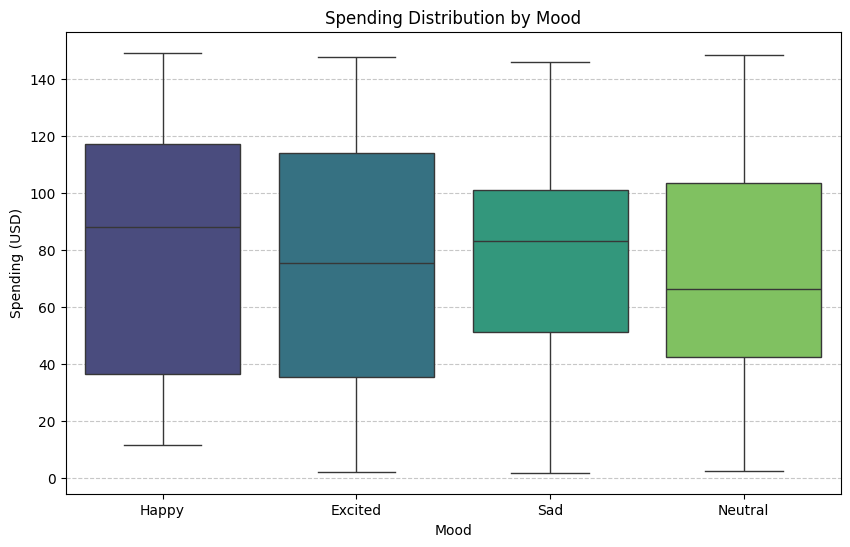

In [31]:
# Visualize the relationship between spending and mood
plt.figure(figsize=(10, 6))
sns.boxplot(x='mood', y='spending_usd', data=df, palette='viridis')
plt.title('Spending Distribution by Mood')
plt.xlabel('Mood')
plt.ylabel('Spending (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [39]:
# Calculate the average age
average_age = df['age'].mean()
average_age

np.float64(31.235)

In [40]:
df['age'].min()

18

## K-Means Clustering on Age

In [37]:
from sklearn.cluster import KMeans

# Prepare data for clustering: select the 'age' column and reshape it
X = df[['age']]

# Initialize KMeans with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')

# Fit the model and predict the clusters
df['age_cluster'] = kmeans.fit_predict(X)

print("Clusters created based on age:")
print(df.groupby('age_cluster')['age'].describe())

Clusters created based on age:
             count       mean       std   min   25%   50%   75%   max
age_cluster                                                          
0            104.0  37.961538  4.274383  31.0  34.0  38.0  42.0  45.0
1             96.0  23.947917  3.894314  18.0  20.0  24.0  27.0  30.0


/tmp/ipykernel_1712/101517646.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age_cluster', y='age', data=df, palette='viridis')


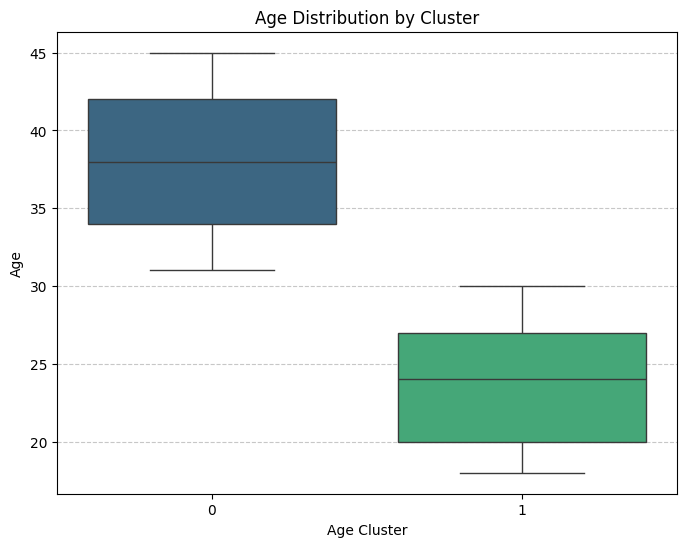

In [38]:
# Visualize the clusters
plt.figure(figsize=(8, 6))
sns.boxplot(x='age_cluster', y='age', data=df, palette='viridis')
plt.title('Age Distribution by Cluster')
plt.xlabel('Age Cluster')
plt.ylabel('Age')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()